# 10. Text-Specific: Embeddings, Masking & Sequence Length — Keras (RNN/LSTM)

Concepts that only apply to the **text** side: what the Embedding actually learns, how **masking** ignores padding, and how much the **sequence length** you keep affects accuracy. (Jena has no analogue for these — it's covered in 11.)

**Two datasets, one concept:**
- **A) IMDB** movie reviews — many-to-one *text classification* (metric: accuracy).
- **B) Jena Climate** weather — sliding-window *temperature forecasting* (metric: MAE).

> Data prep lives in `rnn_data.py`; run `01_sequence_data_prep` once to build the caches.

---

## Setup

In [1]:
import numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import rnn_data as R                      # shared loaders (see rnn_data.py)
keras.utils.set_random_seed(42)
print("TensorFlow", tf.__version__, "| Keras", keras.__version__)

TensorFlow 2.21.0 | Keras 3.14.0


In [2]:
def plot_history(h, metric, title=""):
    """Train (solid) vs validation (dashed): loss on the left, `metric` on the right."""
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h.history["loss"], label="train")
    ax[0].plot(h.history["val_loss"], "--", label="val")
    ax[0].set_title(title + " — loss"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(h.history[metric], label="train")
    ax[1].plot(h.history["val_" + metric], "--", label="val")
    ax[1].set_title(title + " — " + metric); ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

## 1. The Embedding layer up close

An `Embedding` is a trainable `(vocab_size × dim)` lookup table. Row *i* is the vector for word index *i*; the network tunes these during training.

In [3]:
Xtr, ytr, Xte, yte = R.load_imdb(); cfg = R.imdb_config()
emb = layers.Embedding(cfg["num_words"], 16)
_ = emb(Xtr[:1])                       # build the layer
W = emb.get_weights()[0]
print("Embedding table shape:", W.shape, "-> (vocab, dim)")
print("Vector for word index 5:", np.round(W[5], 3))

Embedding table shape: (10000, 16) -> (vocab, dim)
Vector for word index 5: [-0.03   0.047 -0.045 -0.018 -0.026 -0.034  0.036  0.034  0.013  0.004
  0.005  0.021 -0.002 -0.037  0.04  -0.013]


## 2. Masking — telling the RNN to ignore padding

Padded 0s are not real words. `Embedding(..., mask_zero=True)` creates a **mask** so the recurrent layer skips those timesteps instead of treating them as signal.

In [4]:
def build(mask):
    keras.utils.set_random_seed(42)
    m = keras.Sequential([keras.Input((cfg["maxlen"],)),
                          layers.Embedding(cfg["num_words"], 32, mask_zero=mask),
                          layers.LSTM(32), layers.Dense(1, activation="sigmoid")])
    m.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]); return m

h_nomask = build(False).fit(Xtr, ytr, validation_data=(Xte, yte), epochs=3, batch_size=64, verbose=0)
h_mask   = build(True ).fit(Xtr, ytr, validation_data=(Xte, yte), epochs=3, batch_size=64, verbose=0)
print("no masking : test acc %.3f" % max(h_nomask.history["val_accuracy"]))
print("mask_zero  : test acc %.3f" % max(h_mask.history["val_accuracy"]))

no masking : test acc 0.835
mask_zero  : test acc 0.838


## 3. Sequence-length effect

How many tokens do we actually need? We truncate the cached reviews to the **last** `L` tokens and retrain a small LSTM for each `L`.

maxlen  30 -> test acc 0.747


maxlen  60 -> test acc 0.787


maxlen 100 -> test acc 0.827


maxlen 150 -> test acc 0.835


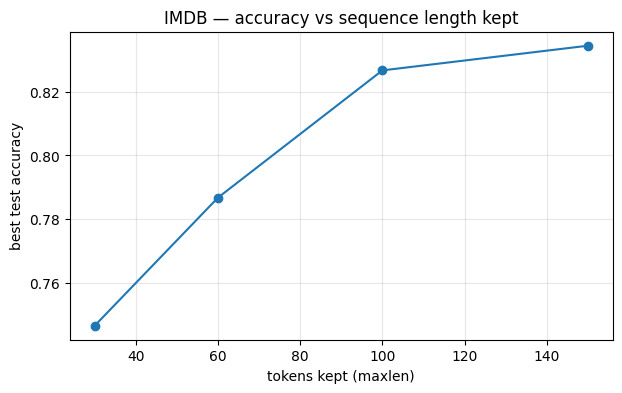

In [5]:
lengths = [30, 60, 100, 150]
acc_by_len = []
for L in lengths:
    keras.utils.set_random_seed(42)
    XtrL, XteL = Xtr[:, -L:], Xte[:, -L:]          # keep the last L tokens
    m = keras.Sequential([keras.Input((L,)),
                          layers.Embedding(cfg["num_words"], 32), layers.LSTM(32),
                          layers.Dense(1, activation="sigmoid")])
    m.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    h = m.fit(XtrL, ytr, validation_data=(XteL, yte), epochs=3, batch_size=64, verbose=0)
    acc_by_len.append(max(h.history["val_accuracy"]))
    print("maxlen %3d -> test acc %.3f" % (L, acc_by_len[-1]))

plt.figure(figsize=(7, 4))
plt.plot(lengths, acc_by_len, marker="o")
plt.title("IMDB — accuracy vs sequence length kept"); plt.xlabel("tokens kept (maxlen)")
plt.ylabel("best test accuracy"); plt.grid(alpha=.3); plt.show()

## Takeaways
- The **Embedding** is just a learned lookup table; its rows become meaningful word vectors as training proceeds (similar-sentiment words drift together).
- **Masking** (`mask_zero=True`) stops the RNN from spending capacity on padding — it usually helps or is neutral, and it's essential for genuinely variable-length batches.
- **Longer sequences carry more signal up to a point**, then plateau — the accuracy-vs-length curve tells you the cheapest maxlen that keeps most of the accuracy (a real speed/accuracy lever).
- **Next:** `11_timeseries_advanced`.